## Pandas 라이브러리

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt    # 데이터 분석 3대장 매우 중요

In [1]:
import numpy as np
import pandas as pd

### series 데이터 구조
- 1차원 형태의 데이터 구조

In [2]:
data = [9904312,3448737,2890451,1466052]

pop = pd.Series(data)   #판다스의 시리즈라고 하는 변수에 데이터를 넣어주겠습니다
pop                     #괄호 안의 데이터를 내가 원하는 구조로 바꾸는 방법

#series는 보통 인덱스 이름을 바꿔서 사용한다ㅏ.

0    9904312
1    3448737
2    2890451
3    1466052
dtype: int64

In [3]:
pop = pd.Series(data, index = ["서울", "부산", "인천", "광주"]) #딕셔너리에서 사용하는 명령어들을 시리즈에서도 사용가능하다.
pop + 1000000  #--->요소별 연산이 가능하다

서울    10904312
부산     4448737
인천     3890451
광주     2466052
dtype: int64

In [4]:
pop.values   #판다스는 원래 없었고 넘파이가 먼저 있었는데 넘파이가 사람이 보기에 불편하게 서술형으로 되어 있어서 파생되어 나온게 판다스임. 그래서 판다스가 어레이의 성질을 그대로 가지고 있어서 array로 나옴

array([9904312, 3448737, 2890451, 1466052])

In [5]:
pop.index

Index(['서울', '부산', '인천', '광주'], dtype='str')

In [6]:
pop = pd.Series(data, index = ["서울", "부산", "인천", "광주"]) 
pop 

서울    9904312
부산    3448737
인천    2890451
광주    1466052
dtype: int64

In [7]:
# series에 이름이 붙어있지 않아서 아무것도 출력이 되지 않음.
pop.name

In [8]:
pop.name = "인구수" #이름을 붙여주면 나옴 # --> 나중에 모이면 DataFrame의 컬럼 이름이 된다!
pop

서울    9904312
부산    3448737
인천    2890451
광주    1466052
Name: 인구수, dtype: int64

In [9]:
pop.index.name = '도시'  #구분칸. 에도 이름을 지어줄수 있다
pop

도시
서울    9904312
부산    3448737
인천    2890451
광주    1466052
Name: 인구수, dtype: int64

### 인덱싱&슬라이싱

In [10]:
pop
# 광주 인구만 보고싶으면?
pop["광주"]
# 이제 바껴서 pop["인덱스 이름"] 만 가능하다. 인덱스 번호를 넣으면 안된다!

np.int64(1466052)

In [11]:
pop[["광주"]]  #2차원으로 만들어줘서 원래 형태를 유지시켜서 출력

도시
광주    1466052
Name: 인구수, dtype: int64

In [12]:
# 슬라이싱
pop["부산":"광주"]   #인덱스 이름으로 슬라이싱 할 때는 끝 값이 포함된 상태로 나온다!

도시
부산    3448737
인천    2890451
광주    1466052
Name: 인구수, dtype: int64

### 불리언 인덱싱

트루 폴스로 나오는거면 다 재료로 사용이 가능하다

In [13]:
pop

# 인구수가 250만 이상인 도시들만 출력해보자
pop >= 2500000  # 재료

도시
서울     True
부산     True
인천     True
광주    False
Name: 인구수, dtype: bool

In [14]:
pop[pop >= 2500000]  #안에 재료 넣어서 인덱싱 해주겠습니다.

도시
서울    9904312
부산    3448737
인천    2890451
Name: 인구수, dtype: int64

In [15]:
 # 문제 : 인구수가 250만 이상이면서 500만 이하인 도시 찾기
# and가 1대1 연산이면 &는 n대n 연산이다
# or 은 n대n |(역슬래쉬)쓰면 됩니다
pop[(pop >= 2500000) & (pop <= 5000000)]  #배열 형태일땐 and 쓰면 안됨


도시
부산    3448737
인천    2890451
Name: 인구수, dtype: int64

#### 딕셔너리로 Series 생성하기

In [16]:
data ={'서울' : 9631482,
             '부산' : 3393191,
             '인천' : 2632035,
             '대전' : 1490158}
data
# 딕셔너리를 사용해서 Series 생성해보기
pop2 = pd.Series(data)
pop2

서울    9631482
부산    3393191
인천    2632035
대전    1490158
dtype: int64

In [17]:
pop

도시
서울    9904312
부산    3448737
인천    2890451
광주    1466052
Name: 인구수, dtype: int64

In [18]:
print(pop.index)
print(pop.values)

Index(['서울', '부산', '인천', '광주'], dtype='str', name='도시')
[9904312 3448737 2890451 1466052]


In [19]:
print(pop2.index)
print(pop2.values)

Index(['서울', '부산', '인천', '대전'], dtype='str')
[9631482 3393191 2632035 1490158]


In [20]:
# 컴퓨터 입장에서 같은 인덱스끼리 연산하는 것이 가능한가?
# 인구 증감률 계산(현재 인구 수에서 과거 인구수를 뺌.)
popu = pop -pop2
popu



#NaN(Not a Number) : 결측치 ---> 어레이는 숫자끼리만 계산이 가능하니까 그외의 문자 등등은 다 결측치로 표시함. 판다스는 문자로 되어있는 인덱스도 찾아서 계산할수있다.

도시
광주         NaN
대전         NaN
부산     55546.0
서울    272830.0
인천    258416.0
dtype: float64

# 결측치 확인 방법
popu.null    #null은 아무것도 없는. 텅빈. 널값은 비교연산이 안됨. 그래서 널이니? 묻고 싶어서 함수로 물어보는 isnull()을씀

In [21]:
popu.isnull()    #재료
                 #파이썬에서 트루는 숫자 1, 폴스는 숫자 0으로 이해한다. 매우 중요

도시
광주     True
대전     True
부산    False
서울    False
인천    False
dtype: bool

In [22]:
popu[popu.isnull()] #불리언 인덱싱을 사용해서 널값을 다 추출. null값만 찾아내는 방법

도시
광주   NaN
대전   NaN
dtype: float64

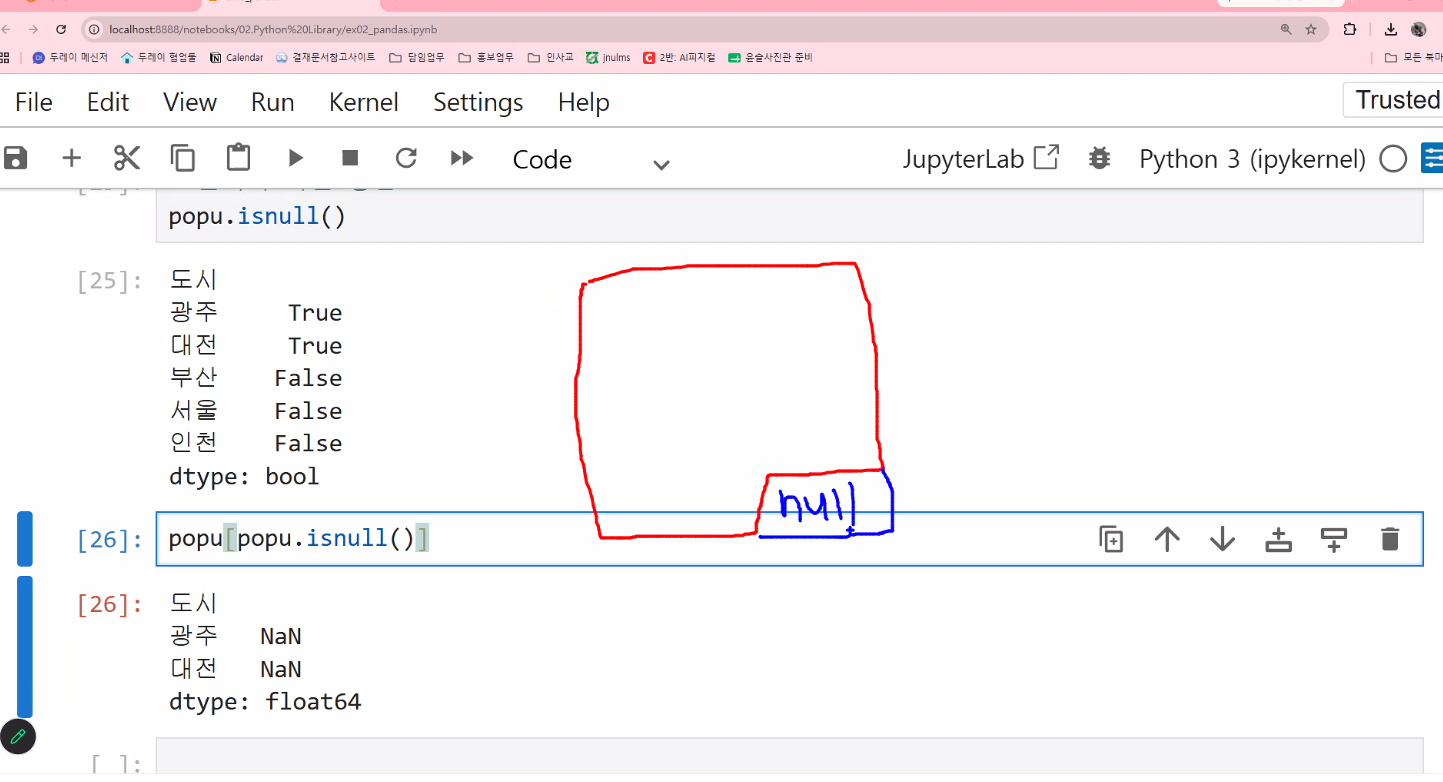

비어있는 값을 그냥 둘수없어서 null로 표시해둠.

In [23]:
popu.isnull().sum()  #결측치가 몇개 있는지 확인하는 방법. #아즈널썸서서 결측치 숫자 확인하고 블리언으로 찾아서 없애고 다시 이즈널썸으로 없어졌는지 확인함.

np.int64(2)

In [24]:
# 인구 증감률(%형태로 구할때)
# (현재 - 과거) / 과거 * 100
rs = popu / pop2 *100
rs

도시
광주         NaN
대전         NaN
부산    1.636984
서울    2.832690
인천    9.818107
dtype: float64

In [25]:
popu.fillna(7)  #결측치 채우는 방법. 대부분 상황에서 결측치를 아예 지워버리진않고 평균값등 다른 값으로 채워준다

도시
광주         7.0
대전         7.0
부산     55546.0
서울    272830.0
인천    258416.0
dtype: float64

### Series 데이터 추가, 수정, 삭제

In [26]:
# 추가, 수정 -> 딕셔너리와 동일한 방법을 사용
rs['대구'] = 1.41  # 기존에 없는 데이터 추가
rs['광주'] = 2.13  # 기존에 있던 데이터 수정
rs

도시
광주    2.130000
대전         NaN
부산    1.636984
서울    2.832690
인천    9.818107
대구    1.410000
dtype: float64

In [27]:
# 삭제
del rs['대전']
rs

도시
광주    2.130000
부산    1.636984
서울    2.832690
인천    9.818107
대구    1.410000
dtype: float64

## DataFrame

In [28]:
data = {"2015" : [9904312, 3448737 , 2890451, 2446052],
              "2010" : [9631482, 3393191, 2632035, 2431774]}

df = pd.DataFrame(data, index = ['서울', '부산', '인천', '광주'])
df                         

,2015,2010
서울,9904312,9631482
부산,3448737,3393191
인천,2890451,2632035
광주,2446052,2431774


In [29]:
lst1 = [[9904312, 3448737 , 2890451, 2446052],
        [9631482, 3393191, 2632035, 2431774]]

df_t = pd.DataFrame(lst1, index = ["2015", "2010"], columns = ['서울', '부산', '인천', '광주'])
df_t.T  #구분 네임 순서 바꾸는 방법

,2015,2010
서울,9904312,9631482
부산,3448737,3393191
인천,2890451,2632035
광주,2446052,2431774


### 데이터프레임 구조 확인

In [30]:
# DataFrame 값 확인
df.values

array([[9904312, 9631482],
       [3448737, 3393191],
       [2890451, 2632035],
       [2446052, 2431774]])

In [31]:
df.index

Index(['서울', '부산', '인천', '광주'], dtype='str')

In [32]:
df.columns #시리즈의 네임이 모이면 데이터프레임의 콜럼스 이름이 된다

Index(['2015', '2010'], dtype='str')

- DataFrame 데이터 추가, 수정, 삭제

In [33]:
df['2005'] = [9762546,3512547,2517680,1456016]
df

,2015,2010,2005
서울,9904312,9631482,9762546
부산,3448737,3393191,3512547
인천,2890451,2632035,2517680
광주,2446052,2431774,1456016


#삭제 --> 데이터 프레임에서는 del 키워드 사용 안함. --> drop() 함수를 사용
df.drop()#드랖은 기본적으로 행 단위부터 삭제를함. #드랖은 변수에 다시 담아줘야 완전 삭제가 된다. df = df.drop() 요런느낌. 그런데이렇게 안쓰고 인플레이스를 사용한다.
        #행이 아니라 열을 삭제하고 싶으면 엑시스를 사용하면 된다. 엑시스(축)이 0이면 행이다. 1로바꾸면 열. df.drop(' ', axis = 1, inplace = True)
# axis = 축 --> 0 : 행, 1 : 열
# inplacr = True --> 삭제하려는 명령어를 영구 반영하겠습니다.

### DataFrame 인덱싱과 슬라이싱

In [34]:
# 인덱싱 --> Series 형태로 출력
df['2015']
# DataFrame이 여러개의 Series로 구성되어 잇기 때문

서울    9904312
부산    3448737
인천    2890451
광주    2446052
Name: 2015, dtype: int64

In [35]:
# 2차원 형태로 꺼내고 싶다면?
df[['2015']]

,2015
서울,9904312
부산,3448737
인천,2890451
광주,2446052


In [36]:
df

,2015,2010,2005
서울,9904312,9631482,9762546
부산,3448737,3393191,3512547
인천,2890451,2632035,2517680
광주,2446052,2431774,1456016


In [37]:
# df['부산' : '인천'] -->은 되는데
# df['2010' : '2005']  ->은 안된다.
# 행 슬라이싱은 가능. 행 인덱싱은 불가능.
# 열 슬라이싱은 불가능. 열 인덱싱은 가능.
#위처럼 복잡하기 때문에 다 가능하게 만들어주는 도구가 인덱서이다.

In [38]:
df

,2015,2010,2005
서울,9904312,9631482,9762546
부산,3448737,3393191,3512547
인천,2890451,2632035,2517680
광주,2446052,2431774,1456016


In [39]:
df.loc['부산':'인천','2015':'2010']   #왼쪽은 행 오른쪽은 열

,2015,2010
부산,3448737,3393191
인천,2890451,2632035


In [40]:
df.loc['부산',:]  #부산이라는 행을 인덱싱해서 열 전체를 불러오겠다 #하나만 인덱싱하면 시리즈로 가져와짐

2015    3448737
2010    3393191
2005    3512547
Name: 부산, dtype: int64

In [41]:
# iloc   --> 인덱스 번호를 사용해서 슬라이싱 하기 때문에 끝 값이 포함되지 않는다
df.iloc[1:3, 0:2] #인덱스 숫자로 가져올수 있다.

,2015,2010
부산,3448737,3393191
인천,2890451,2632035


In [42]:
#추가할때 행으로 추가하는방법.

df.loc['대전'] = [23, 32, 12] #--->열전체로 할떈 콤마 뒤 생략가능. ['대전',:]
df

,2015,2010,2005
서울,9904312,9631482,9762546
부산,3448737,3393191,3512547
인천,2890451,2632035,2517680
광주,2446052,2431774,1456016
대전,23,32,12


#### boolean 인덱싱

In [43]:
df.drop('대전', inplace = True)
df

,2015,2010,2005
서울,9904312,9631482,9762546
부산,3448737,3393191,3512547
인천,2890451,2632035,2517680
광주,2446052,2431774,1456016


In [44]:
df['2010'] >= 2500000

서울     True
부산     True
인천     True
광주    False
Name: 2010, dtype: bool

In [45]:
df[df['2010'] >= 2500000]

,2015,2010,2005
서울,9904312,9631482,9762546
부산,3448737,3393191,3512547
인천,2890451,2632035,2517680


In [46]:
df >= 2600000

,2015,2010,2005
서울,True,True,True
부산,True,True,True
인천,True,True,False
광주,False,False,False


In [47]:
df[df >= 2600000]

,2015,2010,2005
서울,9904312.0,9631482.0,9762546.0
부산,3448737.0,3393191.0,3512547.0
인천,2890451.0,2632035.0,NaN
광주,NaN,NaN,NaN


### DataFrame 실습

In [48]:
score = pd.read_csv('./data/score.csv', encoding = 'utf-8', index_col = '과목')
# pandas에서 제공하는 csv 파일을 읽어오는 함수. pd.read_csv('경로')
# encoding 방식 : euc-kr / utf-8 / cp949 --> 호환성의 차이    #한글을 컴퓨터가 잘 이해해서 깨지지않게 잘불러오도록 하는거. 저장한 사람이 설정한 호환을 맞춰야 열린다.
# index_col : csv파일 안에 있는 컬럼 중 하나를 index로 사용하겠다.
score

,1반,2반,3반,4반
과목,,,,
파이썬,45,44,73,39
DB,76,92,45,69
자바,47,92,45,69
크롤링,92,81,85,40
HTML/CSS,11,79,47,26


In [49]:
# 반 별로 과목의 점수 합계  --> sum()
score.sum() #--->기본 엑시스 값이 0이니까 과목별 점수의 합을 구해줌
            #score.sum(exis=1) 로 하면 과목 반별 점수의 합을 구해

1반    271
2반    388
3반    295
4반    243
dtype: int64

# 1번 실습 : score라는 DataFrame에 "합계" 컬럼 생성 ->  과목별 총합 구하기
score['합계'] = score.sum(axis=1)
score

#2번 실습 : "반 별 합계" 라는 컬럼 생성 -> 반별 총합 구하기
score.loc['반 별 합계'] = score.sum()
score


#### 선생님 풀이

In [50]:
# 1번 실습 : score라는 DataFrame에 "합계" 컬럼 생성 ->  과목별 총합 구하기
score['합계'] = score.loc["파이썬":"HTML/CSS","1반":"4반"].sum(axis = 1) #썸은 1234반 점수뿐 아니라 합계까지 더해서 실행할수록 다 계속 더해짐. 그래서 1반부터 4반까지 잘라서 더해야함
score

,1반,2반,3반,4반,합계
과목,,,,,
파이썬,45,44,73,39,201
DB,76,92,45,69,282
자바,47,92,45,69,253
크롤링,92,81,85,40,298
HTML/CSS,11,79,47,26,163


In [52]:
#2번 실습 : "반 별 합계" 라는 컬럼 생성 -> 반별 총합 구하기
score.sum()
score.loc['반 별 합계'] = score.loc["파이썬":"HTML/CSS","1반":"4반"].sum()
score

,1반,2반,3반,4반,합계
과목,,,,,
파이썬,45.0,44.0,73.0,39.0,201.0
DB,76.0,92.0,45.0,69.0,282.0
자바,47.0,92.0,45.0,69.0,253.0
크롤링,92.0,81.0,85.0,40.0,298.0
HTML/CSS,11.0,79.0,47.0,26.0,163.0
반 별 합계,271.0,388.0,295.0,243.0,NaN


In [58]:
# 3번 실습 : 평균 -> mean() --> 반 별 평균, 과목 별 평균 --> 컬럼 추가
score["과목별 평균"] = score.loc["파이썬":"HTML/CSS","1반":"4반"].mean(axis = 1)
score

score.loc["반 별 평균"] = score.loc["파이썬":"HTML/CSS","1반":"4반"].mean()
score




,1반,2반,3반,4반,합계,과목별 평균
과목,,,,,,
파이썬,45.0,44.0,73.0,39.0,201.0,50.25
DB,76.0,92.0,45.0,69.0,282.0,70.50
자바,47.0,92.0,45.0,69.0,253.0,63.25
크롤링,92.0,81.0,85.0,40.0,298.0,74.50
HTML/CSS,11.0,79.0,47.0,26.0,163.0,40.75
반 별 합계,271.0,388.0,295.0,243.0,NaN,NaN
반 별 평균,54.2,77.6,59.0,48.6,NaN,NaN


In [70]:
score.round().astype("Int64")

,1반,2반,3반,4반,합계,과목별 평균
과목,,,,,,
파이썬,45,44,73,39,201,50
DB,76,92,45,69,282,70
자바,47,92,45,69,253,63
크롤링,92,81,85,40,298,74
HTML/CSS,11,79,47,26,163,41
반 별 합계,271,388,295,243,<NA>,<NA>
반 별 평균,54,78,59,49,<NA>,<NA>


In [68]:
# 4번 실습 : 반 별로 가장 높은 점수와 낮은 점수를 구해서 변수에 넣기
#가장 높은 점수 : max(), 가장 낮은 점수 : min()
#score_max, score_min에 
score_max = score.loc["파이썬":"HTML/CSS","1반":"4반"].max()
score_max


1반    92.0
2반    92.0
3반    85.0
4반    69.0
dtype: float64

In [69]:
score_min = score.loc["파이썬":"HTML/CSS","1반":"4반"].min()
score_min

1반    11.0
2반    44.0
3반    45.0
4반    26.0
dtype: float64

In [71]:
score_max - score_min

1반    81.0
2반    48.0
3반    40.0
4반    43.0
dtype: float64

In [77]:
def max_min(x): 
    return x.max() - x.min()      #함수를 만들어서 데이터 프레임에 바로 적용. x는 자동 으로 점수가 들어오게 해주는.
                                  # for반복문 안써도 됨. 어플라이 함수.

In [75]:
score.loc["파이썬":"HTML/CSS","1반":"4반"].apply(max_min, axis = 1)
#apply함수 : 행이나 열 단위로 더 복합한 처리를 할 때 사용하는 함수
# 보통 pandas 객체에 함수를 일괄 적용할 때 사용하는 방법

과목
파이썬         34.0
DB          47.0
자바          47.0
크롤링         52.0
HTML/CSS    68.0
dtype: float64

## 데이터프레임 정렬

In [80]:
# 인덱스를 사용해서 정렬하는 방법
score.sort_index(ascending=False)   #이제는 정렬할때 기준을 정해줘야 한다. 어센딩(오름차순) 폴스는 리버스.

,1반,2반,3반,4반,합계,과목별 평균
과목,,,,,,
파이썬,45.0,44.0,73.0,39.0,201.0,50.25
크롤링,92.0,81.0,85.0,40.0,298.0,74.50
자바,47.0,92.0,45.0,69.0,253.0,63.25
반 별 합계,271.0,388.0,295.0,243.0,NaN,NaN
반 별 평균,54.2,77.6,59.0,48.6,NaN,NaN
HTML/CSS,11.0,79.0,47.0,26.0,163.0,40.75
DB,76.0,92.0,45.0,69.0,282.0,70.50


In [82]:
#데이터를 기준으로 정렬
score.sort_values(by = '합계') #합계를 기준으로 오름차순

,1반,2반,3반,4반,합계,과목별 평균
과목,,,,,,
HTML/CSS,11.0,79.0,47.0,26.0,163.0,40.75
파이썬,45.0,44.0,73.0,39.0,201.0,50.25
자바,47.0,92.0,45.0,69.0,253.0,63.25
DB,76.0,92.0,45.0,69.0,282.0,70.50
크롤링,92.0,81.0,85.0,40.0,298.0,74.50
반 별 합계,271.0,388.0,295.0,243.0,NaN,NaN
반 별 평균,54.2,77.6,59.0,48.6,NaN,NaN


## 카테고리 생성

In [83]:
# 나이 데이터를 사용해서 카테고리 정렬 
# 1. 데이터 준비
ages = [0, 2, 10, 15, 21, 23, 37, 61, 20, 41, 100, 52, 78]

# 2. 범주 준비
bins = [0, 19, 47, 60, 99]

# 구간 : 초과 ~ 이하
# 0 ~ 19 : 미성년자
# 20 ~ 47 : 청년
# 48 ~ 60 : 중년
# 61 ~ 100 : 노년

# 3. 라벨 준비
labels = ['미성년자', '청년', '중년', '노년']

cate = pd.cut(ages, bins, labels = labels)
cate

[NaN, '미성년자', '미성년자', '미성년자', '청년', ..., '청년', '청년', NaN, '중년', '노년']
Length: 13
Categories (4, str): ['미성년자' < '청년' < '중년' < '노년']

In [84]:
cate.categories

Index(['미성년자', '청년', '중년', '노년'], dtype='str')

In [85]:
age_df = pd.DataFrame(ages, columns = ['나이'])
age_df

,나이
0,0
1,2
2,10
3,15
4,21
5,23
6,37
7,61
8,20
9,41


In [86]:
age_df['연령대'] = cate
age_df

,나이,연령대
0,0,NaN
1,2,미성년자
2,10,미성년자
3,15,미성년자
4,21,청년
5,23,청년
6,37,청년
7,61,노년
8,20,청년
9,41,청년


In [87]:
# value_counts() --> 세어주고 싶은 시리즈의 갯수를 세어줌
age_df['연령대'].value_counts()

연령대
청년      5
미성년자    3
노년      2
중년      1
Name: count, dtype: int64

#### DataFrame 병합

In [88]:
df1 = pd.DataFrame({'A':['A0','A1','A2','A3'],
                                       'B':['B0','B1','B2','B3'],
                                       'C':['C0','C1','C2','C3']},
                                                    index = [0,1,2,3])

df2 = pd.DataFrame({'A':['A4','A5','A6','A7'],
                                        'B':['B4','B5','B6','B7'],
                                        'C':['C4','C5','C6','C7']},
                                                      index= [4,5,6,7])

df3 = pd.DataFrame({'A':['A8','A9','A10','A11'],
                                        'B':['B8','B9','B10','B11'],
                                        'C':['C8','C9','C10','C11']},
                                                      index= [8,9,10,11])

In [89]:
df1

,A,B,C
0,A0,B0,C0
1,A1,B1,C1
2,A2,B2,C2
3,A3,B3,C3


In [90]:
# 데이터 프레임 병합 ==> concat() 이라는 함수 사용. merge()도 있는데 콘캣을 많이 쓴다.
pd.concat([df1,df2,df3])

,A,B,C
0,A0,B0,C0
1,A1,B1,C1
2,A2,B2,C2
3,A3,B3,C3
4,A4,B4,C4
5,A5,B5,C5
6,A6,B6,C6
7,A7,B7,C7
8,A8,B8,C8
9,A9,B9,C9


In [92]:
# 다중인덱스 -->  섞여있는 데이터를 계층적으로 관리하기 위해 사용한다.
pd.concat([df1,df2,df3], keys = ['df1','df2','df3'])

A    B    C
df1 0    A0   B0   C0
    1    A1   B1   C1
    2    A2   B2   C2
    3    A3   B3   C3
df2 4    A4   B4   C4
    5    A5   B5   C5
    6    A6   B6   C6
    7    A7   B7   C7
df3 8    A8   B8   C8
    9    A9   B9   C9
    10  A10  B10  C10
    11  A11  B11  C11

In [93]:
#열단위 병함
pd.concat([df1,df2,df3], axis = 1)

,A,B,C,A,B,C,A,B,C
0,A0,B0,C0,NaN,NaN,NaN,NaN,NaN,NaN
1,A1,B1,C1,NaN,NaN,NaN,NaN,NaN,NaN
2,A2,B2,C2,NaN,NaN,NaN,NaN,NaN,NaN
3,A3,B3,C3,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,A4,B4,C4,NaN,NaN,NaN
5,NaN,NaN,NaN,A5,B5,C5,NaN,NaN,NaN
6,NaN,NaN,NaN,A6,B6,C6,NaN,NaN,NaN
7,NaN,NaN,NaN,A7,B7,C7,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,A8,B8,C8
9,NaN,NaN,NaN,NaN,NaN,NaN,A9,B9,C9


In [95]:
df4 = pd.DataFrame({'B':['B2','B3','B6','B7'],
                                        'D':['D2','D3','D6','D7'],
                                        'F':['F2','F3','F6','F7']},
                                                   index = [2,3,6,7])
df4   # 없는 데이터랑 병합하기

,B,D,F
2,B2,D2,F2
3,B3,D3,F3
6,B6,D6,F6
7,B7,D7,F7


In [97]:
pd.concat([df1, df4], axis = 1)

,A,B,C,B,D,F
0,A0,B0,C0,NaN,NaN,NaN
1,A1,B1,C1,NaN,NaN,NaN
2,A2,B2,C2,B2,D2,F2
3,A3,B3,C3,B3,D3,F3
6,NaN,NaN,NaN,B6,D6,F6
7,NaN,NaN,NaN,B7,D7,F7


In [98]:
pd.concat([df1, df4])

,A,B,C,D,F
0,A0,B0,C0,NaN,NaN
1,A1,B1,C1,NaN,NaN
2,A2,B2,C2,NaN,NaN
3,A3,B3,C3,NaN,NaN
2,NaN,B2,NaN,D2,F2
3,NaN,B3,NaN,D3,F3
6,NaN,B6,NaN,D6,F6
7,NaN,B7,NaN,D7,F7


In [99]:
pd.concat([df1, df4], ignore_index = True) #위처럼 인덱스가 겹치지 않도록 하고싶다~할때 씀. 행에서만 가능

,A,B,C,D,F
0,A0,B0,C0,NaN,NaN
1,A1,B1,C1,NaN,NaN
2,A2,B2,C2,NaN,NaN
3,A3,B3,C3,NaN,NaN
4,NaN,B2,NaN,D2,F2
5,NaN,B3,NaN,D3,F3
6,NaN,B6,NaN,D6,F6
7,NaN,B7,NaN,D7,F7
